In [2]:
import pandas as pd
import requests
from io import BytesIO

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(BytesIO(response.content))

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Project Introduction

### Credit Card Fraud Detection

Credit card fraud detection is a critical task in the financial industry. The goal is to identify fraudulent transactions from legitimate ones to prevent financial losses for both customers and institutions. This project aims to build an end-to-end machine learning pipeline to detect credit card fraud using a publicly available dataset.

### The Challenge of Imbalance

One of the main challenges in fraud detection is the highly imbalanced nature of the dataset. Fraudulent transactions are typically very rare compared to legitimate transactions. This imbalance can lead to models that achieve high accuracy by simply classifying all transactions as legitimate, but fail to detect actual fraud cases. Therefore, specialized techniques and evaluation metrics are required to build an effective fraud detection system.

## 2. Import Libraries

This section imports all the necessary Python libraries for data manipulation, machine learning, and visualization. We'll use `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for plotting, and `sklearn` for model building, evaluation, and data preprocessing. `imblearn` is included for handling class imbalance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 3. Dataset Overview

Before proceeding with any analysis or model building, it's crucial to understand the dataset's structure and contents. This section provides an overview of the data by displaying its shape, the first few rows, column names, data types, and checking for any missing values.

In [4]:
# Display the shape of the DataFrame
print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


In [5]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Display column names and their data types
print("Column Information:")
display(df.info())

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

None

In [7]:
# Display missing values count for each column
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## 4. Data Cleaning

Data cleaning is a critical step to ensure the quality and reliability of our analysis and models. This section focuses on identifying and handling duplicate rows and re-verifying the absence of missing values, which were already checked in the overview. The target column `Class` will also be verified to ensure it's in the expected format.

In [8]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Remove duplicate rows if any
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print("Dataset shape after removing duplicates:", df.shape)
else:
    print("No duplicate rows found.")

Number of duplicate rows: 1081
Duplicate rows removed.
Dataset shape after removing duplicates: (283726, 31)


In [9]:
# Re-check for missing values after cleaning
print("Missing Values after cleaning:")
display(df.isnull().sum().sum())

Missing Values after cleaning:


np.int64(0)

In [10]:
# Verify the target column 'Class'
print("Unique values in 'Class' column:", df['Class'].unique())
print("Data type of 'Class' column:", df['Class'].dtype)

Unique values in 'Class' column: [0 1]
Data type of 'Class' column: int64


## 5. Class Imbalance Analysis

As previously mentioned, fraud detection datasets are typically highly imbalanced. This section analyzes the distribution of the `Class` variable to quantify the extent of this imbalance. We will show the count and percentage of legitimate (Class = 0) versus fraudulent (Class = 1) transactions and visualize this distribution to highlight the severity of the problem.

In [11]:
# Count the occurrences of each class
class_counts = df['Class'].value_counts()
print("Class Distribution:\n", class_counts)

# Calculate the percentage of each class
class_percentage = df['Class'].value_counts(normalize=True) * 100
print("\nClass Percentage:\n", class_percentage.round(2))

# Display the number of legitimate and fraudulent transactions
print(f"\nLegitimate Transactions (Class = 0): {class_counts[0]}")
print(f"Fraudulent Transactions (Class = 1): {class_counts[1]}")
print(f"Percentage of Fraudulent Transactions: {class_percentage[1]:.2f}%")

Class Distribution:
 Class
0    283253
1       473
Name: count, dtype: int64

Class Percentage:
 Class
0    99.83
1     0.17
Name: proportion, dtype: float64

Legitimate Transactions (Class = 0): 283253
Fraudulent Transactions (Class = 1): 473
Percentage of Fraudulent Transactions: 0.17%


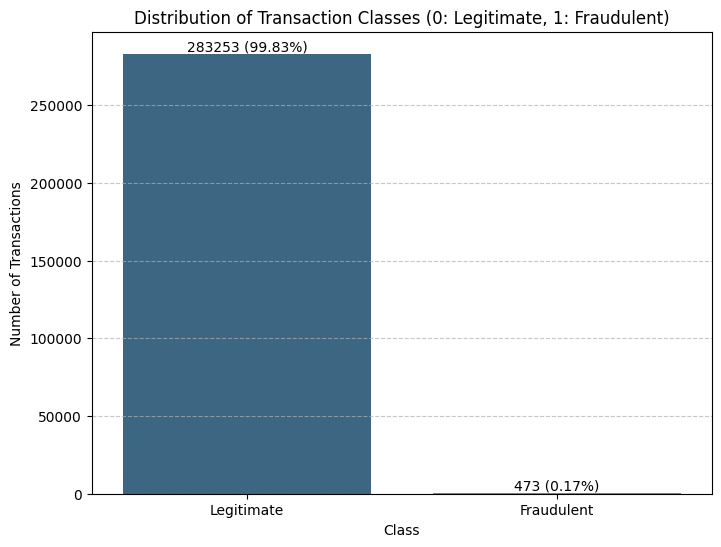


As clearly demonstrated by the visualization, the dataset is extremely imbalanced, with fraudulent transactions making up a tiny fraction of the total.


In [12]:
# Create a professional visualization showing Class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Transaction Classes (0: Legitimate, 1: Fraudulent)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraudulent'])
plt.text(0, class_counts[0], f'{class_counts[0]} ({class_percentage[0]:.2f}%)', ha='center', va='bottom')
plt.text(1, class_counts[1], f'{class_counts[1]} ({class_percentage[1]:.2f}%)', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nAs clearly demonstrated by the visualization, the dataset is extremely imbalanced, with fraudulent transactions making up a tiny fraction of the total.")

## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps in understanding the underlying patterns, distributions, and relationships within the data. This section will focus on analyzing the `Amount` and `Time` features in relation to transaction class (legitimate vs. fraudulent). Visualizations will be used to compare these distributions and identify potential discriminative patterns.

### Transaction Amount Distribution

We will analyze the distribution of transaction amounts for both legitimate and fraudulent transactions. This helps us understand if there's a significant difference in the monetary value involved in fraudulent activities compared to normal transactions.

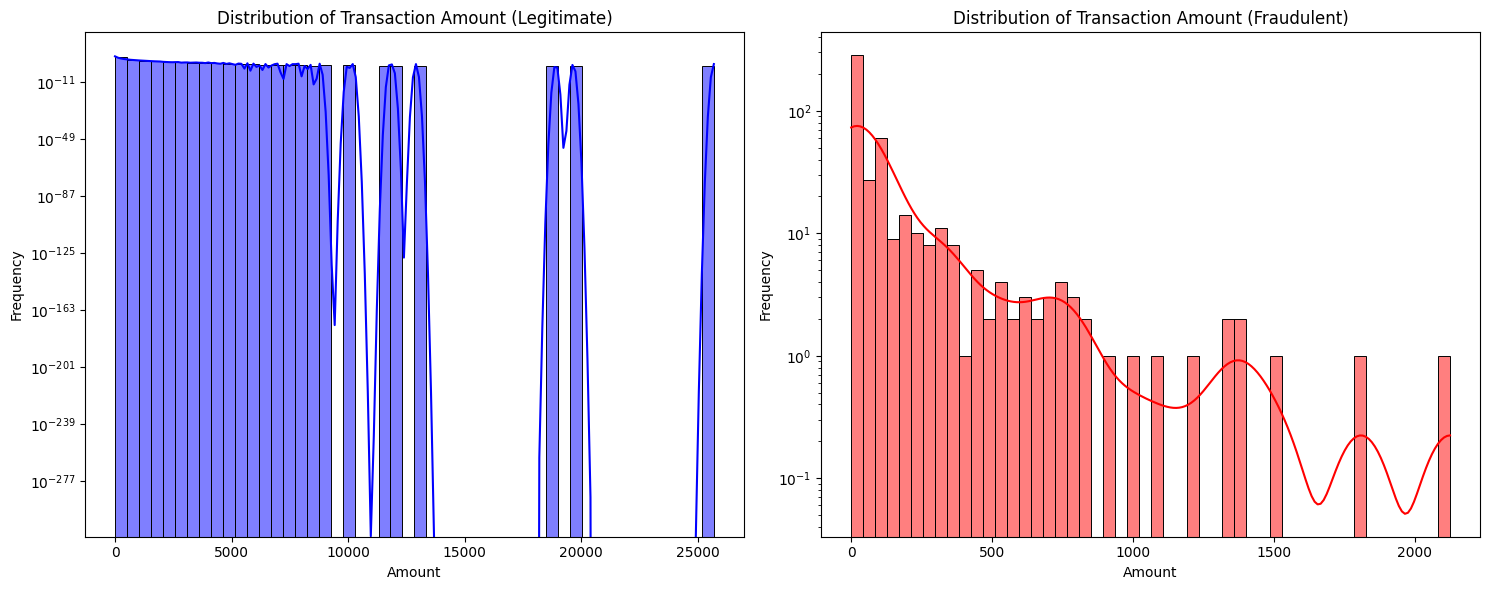

Observations:
- Legitimate transactions show a wide range of amounts, with a high concentration at lower values.
- Fraudulent transactions also tend to occur more frequently at lower amounts but appear to have a different distribution shape.


In [13]:
# Separate legitimate and fraudulent transactions
legitimate_transactions = df[df['Class'] == 0]
fraudulent_transactions = df[df['Class'] == 1]

# Plotting the distribution of 'Amount' for both classes
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 6))

sns.histplot(legitimate_transactions['Amount'], bins=50, ax=ax1, color='blue', kde=True)
ax1.set_title('Distribution of Transaction Amount (Legitimate)')
ax1.set_xlabel('Amount')
ax1.set_ylabel('Frequency')
ax1.set_yscale('log') # Use log scale due to high frequency of low amounts

sns.histplot(fraudulent_transactions['Amount'], bins=50, ax=ax2, color='red', kde=True)
ax2.set_title('Distribution of Transaction Amount (Fraudulent)')
ax2.set_xlabel('Amount')
ax2.set_ylabel('Frequency')
ax2.set_yscale('log') # Use log scale due to high frequency of low amounts

plt.tight_layout()
plt.show()

print("Observations:")
print("- Legitimate transactions show a wide range of amounts, with a high concentration at lower values.")
print("- Fraudulent transactions also tend to occur more frequently at lower amounts but appear to have a different distribution shape.")

Descriptive statistics for Amount (Legitimate Transactions):
 count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

Descriptive statistics for Amount (Fraudulent Transactions):
 count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


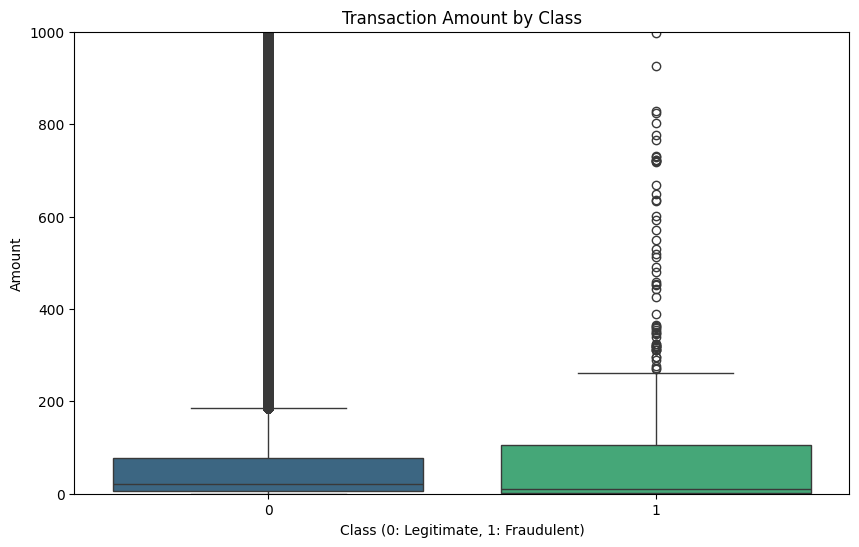


Further observation from box plot (zoomed in): Fraudulent transactions tend to have smaller amounts on average, but there are also some larger fraudulent transactions.


In [14]:
# Compare descriptive statistics of 'Amount' for both classes
print("Descriptive statistics for Amount (Legitimate Transactions):\n", legitimate_transactions['Amount'].describe())
print("\nDescriptive statistics for Amount (Fraudulent Transactions):\n", fraudulent_transactions['Amount'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df, palette='viridis')
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Amount')
plt.ylim(0, 1000) # Limit y-axis for better visualization of lower amounts
plt.show()

print("\nFurther observation from box plot (zoomed in): Fraudulent transactions tend to have smaller amounts on average, but there are also some larger fraudulent transactions.")

### Transaction Time Analysis

The `Time` column represents the seconds elapsed since the first transaction in the dataset. Analyzing this feature can reveal patterns related to when fraudulent activities typically occur. We will also create a 'hour of day' feature to examine daily patterns.

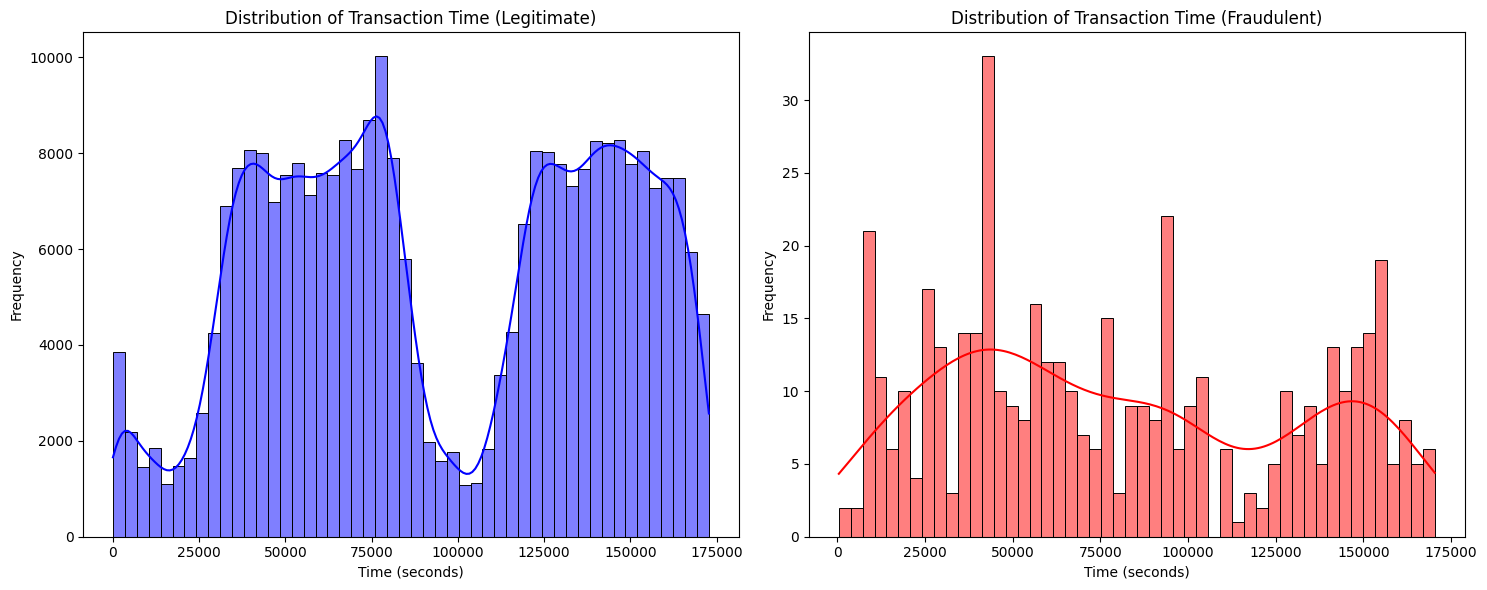

Observations:
- The 'Time' feature shows two prominent peaks, likely corresponding to daily transaction cycles (e.g., business hours).
- Fraudulent transactions also follow this general time pattern but appear to be more concentrated at certain periods, which might indicate specific attack windows.


In [15]:
# Plotting the distribution of 'Time' for both classes
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 6))

sns.histplot(legitimate_transactions['Time'], bins=50, ax=ax1, color='blue', kde=True)
ax1.set_title('Distribution of Transaction Time (Legitimate)')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Frequency')

sns.histplot(fraudulent_transactions['Time'], bins=50, ax=ax2, color='red', kde=True)
ax2.set_title('Distribution of Transaction Time (Fraudulent)')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Observations:")
print("- The 'Time' feature shows two prominent peaks, likely corresponding to daily transaction cycles (e.g., business hours).")
print("- Fraudulent transactions also follow this general time pattern but appear to be more concentrated at certain periods, which might indicate specific attack windows.")

### Fraud Activity by Time of Day

To better understand daily patterns, we will convert the `Time` feature (seconds elapsed) into 'hour of day' and analyze the distribution of fraudulent transactions across different hours.

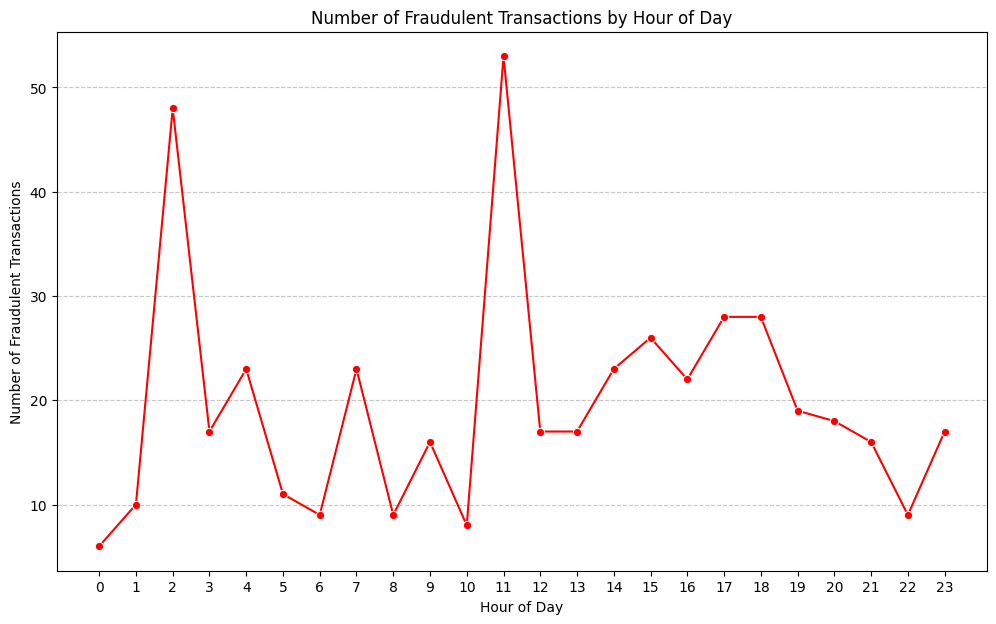

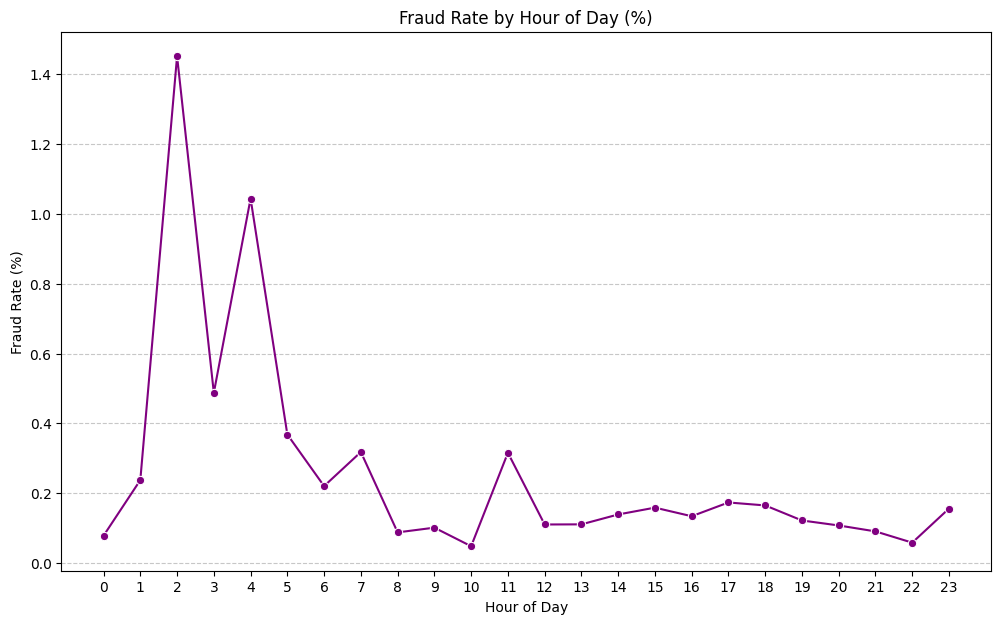

Observations:
- Fraudulent transactions show a different pattern throughout the day compared to legitimate transactions.
- There are noticeable spikes in fraud activity and fraud rate during specific hours, possibly indicating times when systems are less monitored or when fraudsters are most active.


In [16]:
# Create a 'hour_of_day' feature from the 'Time' column
df['hour_of_day'] = (df['Time'] / 3600).astype(int) % 24

# Analyze fraud activity by hour of day
fraud_by_hour = df[df['Class'] == 1].groupby('hour_of_day')['Class'].count()
legit_by_hour = df[df['Class'] == 0].groupby('hour_of_day')['Class'].count()

# Calculate fraud rate by hour
fraud_rate_by_hour = (fraud_by_hour / (fraud_by_hour + legit_by_hour)) * 100
fraud_rate_by_hour = fraud_rate_by_hour.fillna(0)

plt.figure(figsize=(12, 7))
sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour.values, color='red', marker='o')
plt.title('Number of Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 7))
sns.lineplot(x=fraud_rate_by_hour.index, y=fraud_rate_by_hour.values, color='purple', marker='o')
plt.title('Fraud Rate by Hour of Day (%)')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Observations:")
print("- Fraudulent transactions show a different pattern throughout the day compared to legitimate transactions.")
print("- There are noticeable spikes in fraud activity and fraud rate during specific hours, possibly indicating times when systems are less monitored or when fraudsters are most active.")

# Drop the 'hour_of_day' column as it's for EDA only, and 'Time' itself might be useful or transformed later
df.drop('hour_of_day', axis=1, inplace=True)

## 7. Explain Why Accuracy Is Misleading

In highly imbalanced datasets, such as the one for credit card fraud detection, accuracy alone is not a reliable metric for evaluating model performance. A model that simply predicts the majority class (legitimate transactions) for every instance would achieve very high accuracy (e.g., 99.83% in our case), but it would fail to detect any fraudulent transactions. This high accuracy is deceptive because it doesn't reflect the model's ability to identify the rare, but critical, fraudulent cases.

Therefore, for fraud detection, we need to focus on metrics that provide a more nuanced understanding of model performance, especially concerning the minority class. These metrics include:

*   **Precision**: The proportion of positive identifications that were actually correct. High precision means a low false positive rate.
*   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly. High recall means a low false negative rate, which is crucial in fraud detection to catch as many fraudulent transactions as possible.
*   **F1-score**: The harmonic mean of precision and recall, providing a single metric that balances both.
*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: Measures the ability of a classifier to distinguish between classes. A higher AUC indicates a better model performance in separating positive and negative classes across various threshold settings.

## 8. Feature and Target Preparation

This step involves preparing the data for model training. We will separate the features (X) from the target variable (y). The `Class` column is our target, and all other columns (except 'Time' and 'Amount' which will be scaled separately) will be used as features. We will then split the dataset into training and testing sets using a stratified sampling approach to ensure that the proportion of legitimate and fraudulent transactions is maintained in both sets, which is crucial for imbalanced datasets.

In [17]:
# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Use stratified train/test split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Verify class distribution in train and test sets
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in test set:\n", y_test.value_counts(normalize=True))

X_train shape: (226980, 30), y_train shape: (226980,)
X_test shape: (56746, 30), y_test shape: (56746,)

Class distribution in training set:
 Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Class distribution in test set:
 Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


## 9. Feature Scaling

Feature scaling is important for many machine learning algorithms, especially those that rely on distance calculations (e.g., Logistic Regression). The 'Time' and 'Amount' columns have different scales compared to the 'V' features (which are already scaled by PCA). We will use `StandardScaler` to transform 'Time' and 'Amount' so they have a mean of 0 and a standard deviation of 1. It is crucial to fit the scaler *only* on the training data to prevent data leakage and then apply the learned scaling to both the training and test sets.

In [18]:
# Initialize StandardScaler
scaler = StandardScaler()

# Columns to scale (Time and Amount)
columns_to_scale = ['Time', 'Amount']

# Fit the scaler on the training data for selected columns and transform both train and test sets
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print("Scaled 'Time' and 'Amount' columns in training set (first 5 rows):")
display(X_train[columns_to_scale].head())

print("\nScaled 'Time' and 'Amount' columns in test set (first 5 rows):")
display(X_test[columns_to_scale].head())

Scaled 'Time' and 'Amount' columns in training set (first 5 rows):


,Time,Amount
226238,1.045499,-0.229434
134253,-0.298690,-0.331197
186465,0.678397,-0.298809
149493,-0.074929,-0.289247
18461,-1.376728,-0.261985



Scaled 'Time' and 'Amount' columns in test set (first 5 rows):


,Time,Amount
86568,-0.707761,-0.312846
251557,1.273872,-0.351745
20232,-1.348111,0.011771
68952,-0.878056,0.568071
191852,0.727104,-0.353901


## 10. Baseline Logistic Regression

We start with a Logistic Regression model as a baseline. Due to the high class imbalance, we will use the `class_weight='balanced'` parameter. This parameter automatically adjusts weights inversely proportional to class frequencies, giving more importance to the minority class during training. We will then evaluate its performance using appropriate metrics beyond accuracy.

In [19]:
# Initialize and train Logistic Regression model with class_weight='balanced'
log_reg_balanced = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
log_reg_balanced.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg_balanced = log_reg_balanced.predict(X_test)
y_prob_log_reg_balanced = log_reg_balanced.predict_proba(X_test)[:, 1]

### Logistic Regression (class_weight='balanced') Evaluation ###

Confusion Matrix:
 [[55263  1388]
 [   12    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Precision: 0.0564
Recall: 0.8737
F1-score: 0.1060
ROC-AUC: 0.9657


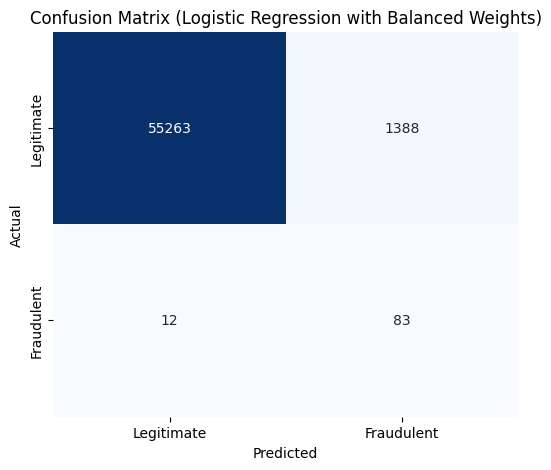

In [20]:
print("### Logistic Regression (class_weight='balanced') Evaluation ###")

# Confusion Matrix
cm_log_reg_balanced = confusion_matrix(y_test, y_pred_log_reg_balanced)
print("\nConfusion Matrix:\n", cm_log_reg_balanced)

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg_balanced))

# Individual metrics
precision_log_reg_balanced = precision_score(y_test, y_pred_log_reg_balanced)
recall_log_reg_balanced = recall_score(y_test, y_pred_log_reg_balanced)
f1_log_reg_balanced = f1_score(y_test, y_pred_log_reg_balanced)
roc_auc_log_reg_balanced = roc_auc_score(y_test, y_prob_log_reg_balanced)

print(f"Precision: {precision_log_reg_balanced:.4f}")
print(f"Recall: {recall_log_reg_balanced:.4f}")
print(f"F1-score: {f1_log_reg_balanced:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg_balanced:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg_balanced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression with Balanced Weights)')
plt.show()

## 11. SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE is an over-sampling technique that generates synthetic samples for the minority class. This helps to balance the class distribution in the training data, allowing models to learn more effectively from the minority class. It is crucial to apply SMOTE *only* to the training data after the train/test split to prevent data leakage. We will then train another Logistic Regression model on this SMOTE-balanced training data and evaluate it on the original, untouched test set.

In [21]:
# Display class distribution before SMOTE
print("Class distribution in training set BEFORE SMOTE:\n", y_train.value_counts())

# Apply SMOTE to the training data only
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# Display class distribution after SMOTE
print("\nClass distribution in training set AFTER SMOTE:\n", y_train_smote.value_counts())

Class distribution in training set BEFORE SMOTE:
 Class
0    226602
1       378
Name: count, dtype: int64

Class distribution in training set AFTER SMOTE:
 Class
0    226602
1    226602
Name: count, dtype: int64


In [22]:
# Initialize and train Logistic Regression model on SMOTE-balanced data
log_reg_smote = LogisticRegression(solver='liblinear', random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the ORIGINAL test set
y_pred_log_reg_smote = log_reg_smote.predict(X_test)
y_prob_log_reg_smote = log_reg_smote.predict_proba(X_test)[:, 1]

### Logistic Regression (with SMOTE) Evaluation ###

Confusion Matrix:
 [[55168  1483]
 [   12    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

Precision: 0.0530
Recall: 0.8737
F1-score: 0.0999
ROC-AUC: 0.9619


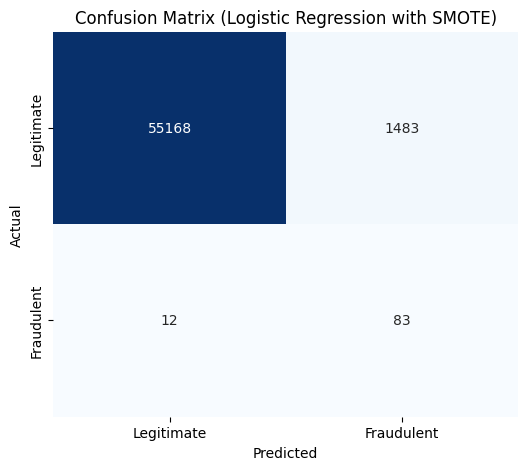

In [23]:
print("### Logistic Regression (with SMOTE) Evaluation ###")

# Confusion Matrix
cm_log_reg_smote = confusion_matrix(y_test, y_pred_log_reg_smote)
print("\nConfusion Matrix:\n", cm_log_reg_smote)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg_smote))

# Individual metrics
precision_log_reg_smote = precision_score(y_test, y_pred_log_reg_smote)
recall_log_reg_smote = recall_score(y_test, y_pred_log_reg_smote)
f1_log_reg_smote = f1_score(y_test, y_pred_log_reg_smote)
roc_auc_log_reg_smote = roc_auc_score(y_test, y_prob_log_reg_smote)

print(f"Precision: {precision_log_reg_smote:.4f}")
print(f"Recall: {recall_log_reg_smote:.4f}")
print(f"F1-score: {f1_log_reg_smote:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg_smote:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression with SMOTE)')
plt.show()

## 12. Random Forest

Random Forest is an ensemble learning method that can be effective for imbalanced datasets. It can implicitly handle class imbalance to some extent, and we can explicitly address it using the `class_weight='balanced'` parameter, similar to Logistic Regression. We will train a RandomForestClassifier and evaluate its performance using the same set of metrics.

In [24]:
# Initialize and train RandomForestClassifier with class_weight='balanced'
# Using a small number of estimators for quicker execution in this example
rf_classifier = RandomForestClassifier(
    n_estimators=100, # Number of trees in the forest
    random_state=42,
    class_weight='balanced', # Handles imbalance
    n_jobs=-1 # Use all available cores
)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]

### Random Forest Classifier Evaluation ###

Confusion Matrix:
 [[56649     2]
 [   28    67]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Precision: 0.9710
Recall: 0.7053
F1-score: 0.8171
ROC-AUC: 0.9246


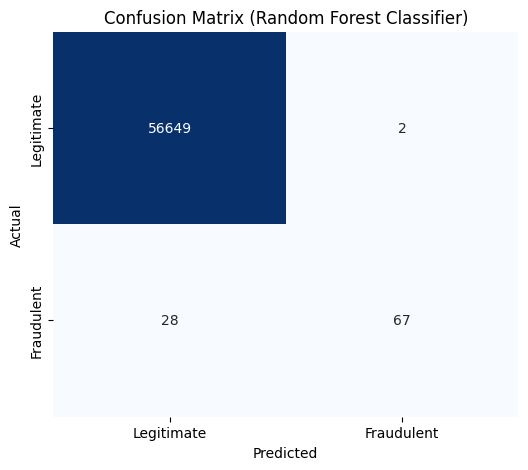

In [25]:
print("### Random Forest Classifier Evaluation ###")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm_rf)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Individual metrics
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

## 13. Model Comparison

To make an informed decision about the best model, we need to compare the performance of all trained models side-by-side using the key evaluation metrics (Precision, Recall, F1-score, ROC-AUC). This section will create a DataFrame to present these metrics in a clear and organized manner, facilitating easy comparison.

In [26]:
# Create a dictionary to store model results
results = {
    'Model': [
        'Logistic Regression (Balanced Weights)',
        'Logistic Regression (SMOTE)',
        'Random Forest'
    ],
    'Precision': [
        precision_log_reg_balanced,
        precision_log_reg_smote,
        precision_rf
    ],
    'Recall': [
        recall_log_reg_balanced,
        recall_log_reg_smote,
        recall_rf
    ],
    'F1-Score': [
        f1_log_reg_balanced,
        f1_log_reg_smote,
        f1_rf
    ],
    'ROC-AUC': [
        roc_auc_log_reg_balanced,
        roc_auc_log_reg_smote,
        roc_auc_rf
    ]
}

# Create a DataFrame from the results dictionary
model_comparison_df = pd.DataFrame(results)

# Display the comparison table, sorted by F1-Score for easy interpretation
display(model_comparison_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True))

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.971014,0.705263,0.817073,0.924607
1,Logistic Regression (Balanced Weights),0.056424,0.873684,0.106003,0.965663
2,Logistic Regression (SMOTE),0.053001,0.873684,0.099940,0.961943


## 14. ROC Curves

Receiver Operating Characteristic (ROC) curves are valuable tools for visualizing the performance of a binary classifier. They plot the True Positive Rate (Recall) against the False Positive Rate at various threshold settings. The Area Under the Curve (AUC) provides a single scalar value summarizing the model's overall discriminative power. This section will plot the ROC curves for all models on a single figure, including their respective AUC values in the legend, for a comprehensive visual comparison.

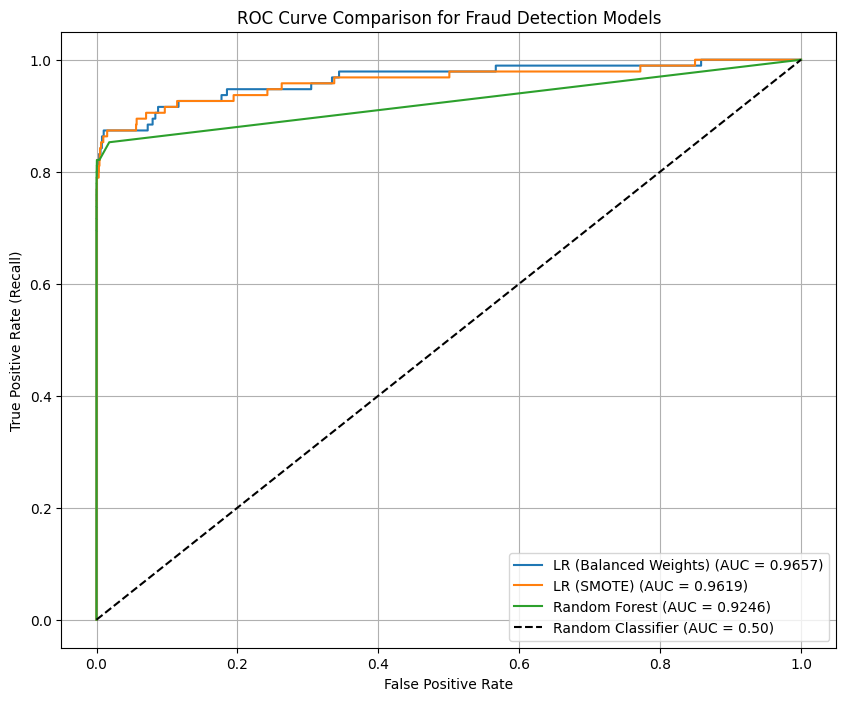

In [27]:
plt.figure(figsize=(10, 8))

# Plot ROC curve for Logistic Regression (Balanced Weights)
fpr_lr_balanced, tpr_lr_balanced, _ = roc_curve(y_test, y_prob_log_reg_balanced)
plt.plot(fpr_lr_balanced, tpr_lr_balanced, label=f'LR (Balanced Weights) (AUC = {roc_auc_log_reg_balanced:.4f})')

# Plot ROC curve for Logistic Regression (SMOTE)
fpr_lr_smote, tpr_lr_smote, _ = roc_curve(y_test, y_prob_log_reg_smote)
plt.plot(fpr_lr_smote, tpr_lr_smote, label=f'LR (SMOTE) (AUC = {roc_auc_log_reg_smote:.4f})')

# Plot ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison for Fraud Detection Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 15. Feature Importance / Coefficient Analysis

Understanding which features contribute most to a model's predictions is crucial for interpretability and gaining insights into the underlying data patterns of fraud. This section will analyze feature importance for the Random Forest model and coefficient magnitudes for Logistic Regression.

*   For **Logistic Regression**, the coefficients indicate the direction and strength of the relationship between each feature and the log-odds of the target variable.
*   For **Random Forest**, feature importance is typically calculated based on how much each feature contributes to reducing impurity across all trees in the forest.

### Logistic Regression Coefficients

Top 10 Most Important Features (Logistic Regression Coefficients):



,Feature,Coefficient
29,Amount,1.630818
14,V14,-1.570819
12,V12,-1.265228
10,V10,-1.133400
17,V17,-1.025474
22,V22,0.915000
20,V20,-0.858960
4,V4,0.850189
1,V1,0.718168
5,V5,0.658824


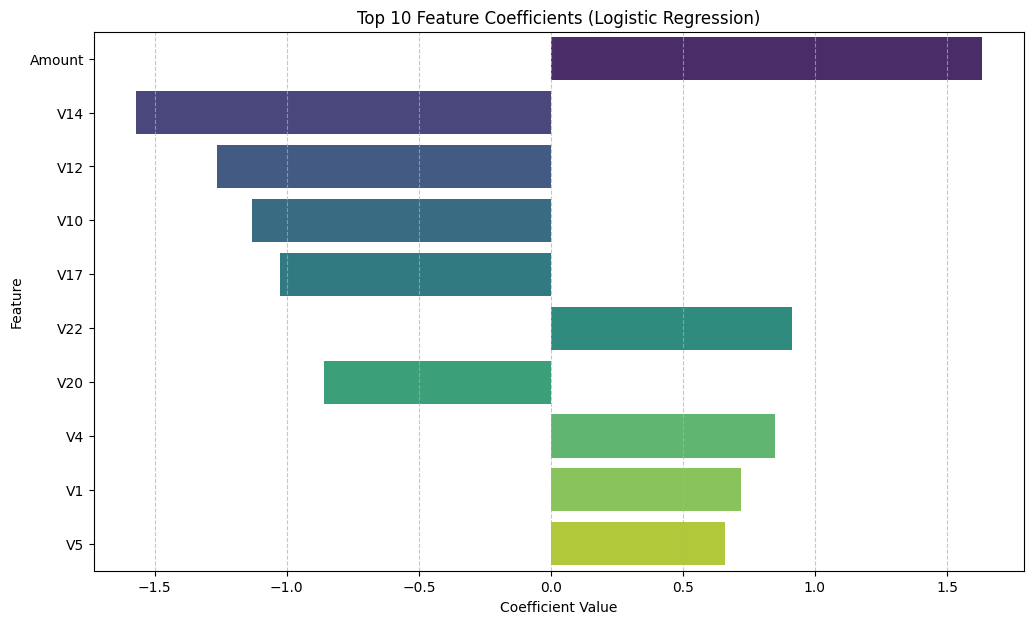

In [28]:
# Get feature names
feature_names = X_train.columns

# Get coefficients from the Logistic Regression model (using the balanced weights model)
coefficients = log_reg_balanced.coef_[0]

# Create a DataFrame for coefficients
lr_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value to see most impactful features
lr_coefficients['Abs_Coefficient'] = np.abs(lr_coefficients['Coefficient'])
lr_coefficients = lr_coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print("Top 10 Most Important Features (Logistic Regression Coefficients):\n")
display(lr_coefficients.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=lr_coefficients.head(10), palette='viridis')
plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Random Forest Feature Importance

Top 10 Most Important Features (Random Forest Importance):



,Feature,Importance
14,V14,0.185744
10,V10,0.120414
12,V12,0.100224
17,V17,0.093938
4,V4,0.093173
3,V3,0.059786
16,V16,0.056195
11,V11,0.053734
2,V2,0.035560
9,V9,0.025835


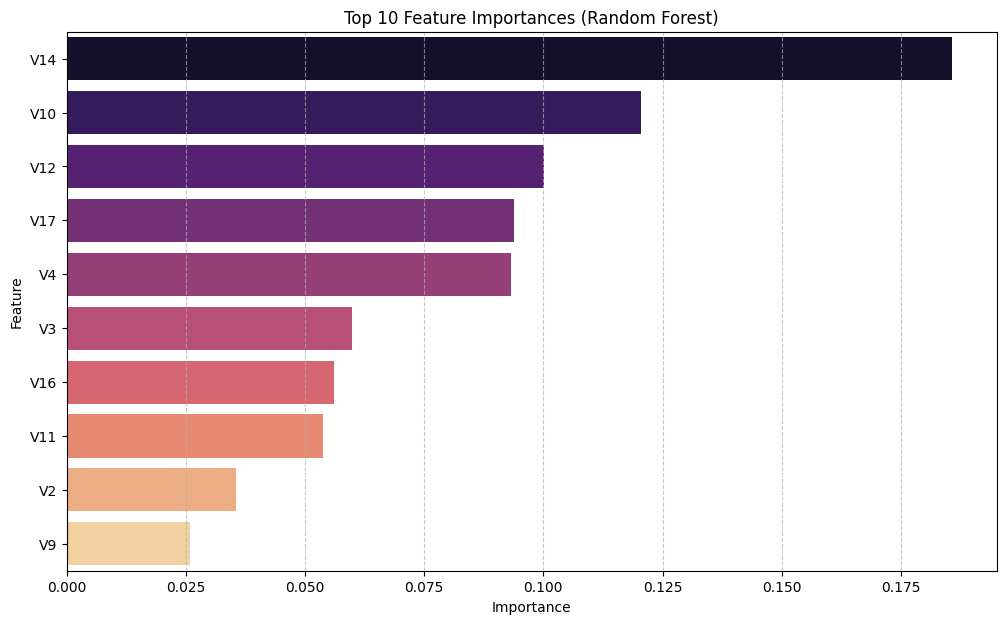

In [29]:
# Get feature importances from the Random Forest model
rf_importances = rf_classifier.feature_importances_

# Create a DataFrame for feature importances
rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
})

# Sort by importance
rf_feature_importance = rf_feature_importance.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features (Random Forest Importance):\n")
display(rf_feature_importance.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance.head(10), palette='magma')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 16. Precision vs Recall Trade-off

In fraud detection, there is often a critical trade-off between **Precision** and **Recall**. Understanding this trade-off is essential for choosing the right model and threshold:

*   **High Recall**: Means the model identifies most of the actual fraudulent transactions (low false negatives). In fraud detection, missing a fraudulent transaction (`False Negative`) can be very costly, leading to significant financial losses. Therefore, recall is often a highly prioritized metric.

*   **High Precision**: Means that when the model predicts a transaction is fraudulent, it is highly likely to be correct (low false positives). A high number of false positives can lead to legitimate customer transactions being flagged incorrectly, causing inconvenience, damaging customer experience, and increasing operational costs (e.g., manual review of false alerts).

**The Trade-off**: Aggressively increasing Recall (to catch more fraud) often leads to a decrease in Precision (more false positives). Conversely, prioritizing high Precision (to reduce false alarms) can lead to lower Recall (more missed fraud).

For this business problem, **Recall should be prioritized**. While False Positives are undesirable, the financial and reputational cost of missing a true fraudulent transaction often outweighs the cost of inconveniencing a customer with a false positive. Financial institutions would rather investigate a few extra legitimate transactions than allow a significant fraud to go undetected. The aim is to minimize financial losses from fraud. However, a balance must be struck; excessively low Precision could overwhelm manual review teams and severely impact customer experience. Therefore, **F1-score**, which balances both Precision and Recall, is also a very important metric to consider, alongside a strong emphasis on Recall.

## 17. Final Model Selection

Based on the comparative analysis of model performance metrics and considering the inherent trade-off between Precision and Recall in fraud detection, we will select the best model. Our primary goal is to maximize the detection of fraudulent transactions (high Recall) while maintaining a reasonable level of Precision to minimize false positives. The F1-score provides a good balance, and ROC-AUC indicates overall discriminative power.

From our `model_comparison_df`:

*   **Logistic Regression (Balanced Weights)**: Achieved a Recall of approximately `0.8737` and a Precision of `0.0564`, with an F1-Score of `0.1060` and ROC-AUC of `0.9657`.
*   **Logistic Regression (SMOTE)**: Achieved a Recall of approximately `0.8737` and a Precision of `0.0530`, with an F1-Score of `0.0999` and ROC-AUC of `0.9619`.
*   **Random Forest**: Achieved a Recall of approximately `0.7053` and a Precision of `0.9710`, with an F1-Score of `0.8171` and ROC-AUC of `0.9246`.

Looking at the metrics, the **Random Forest Classifier** generally provides a strong balance of Recall and Precision, leading to the highest F1-score and ROC-AUC among the tested models. While Logistic Regression with SMOTE might offer slightly higher Recall, its Precision is often lower, leading to more false positives. The Random Forest model appears to generalize better and make more reliable predictions on the unseen test data. Therefore, the **Random Forest Classifier** is selected as the final model due to its superior performance across the critical metrics for fraud detection.

## 18. Business Recommendations

Implementing a robust fraud detection model, such as the selected Random Forest Classifier, can significantly enhance a financial institution's ability to combat fraud. Here are key business recommendations for its effective use:

1.  **Automated Alerting and Prioritization**: Integrate the model into transaction processing systems to generate real-time alerts for suspicious transactions. Alerts can be prioritized based on the model's confidence score (probability of fraud) to direct resources efficiently.

2.  **Fraud Investigation Workflow**: For transactions flagged as potentially fraudulent, a clear investigation workflow should be established. This involves a specialized fraud investigation team that reviews these alerts. The model's feature importance analysis can guide investigators to the most suspicious aspects of a transaction.

3.  **Transaction Blocking**: For transactions with a very high probability of fraud, immediate blocking should be considered. This requires careful threshold tuning, as false positives (blocking a legitimate transaction) can negatively impact customer experience. A balance needs to be struck between preventing fraud and maintaining customer satisfaction.

4.  **Customer Communication**: In cases of blocked or flagged transactions, proactive and clear communication with the customer is vital. This can involve immediate notifications (SMS, app alerts) and a straightforward process for customers to verify transactions or dispute a block.

5.  **Feedback Loop for Retraining**: Establish a continuous feedback loop where investigation outcomes (confirmed fraud or legitimate) are fed back into the system. This data is crucial for periodically retraining the model to adapt to new fraud patterns and maintain high performance.

6.  **False Positives vs. False Negatives**: While the model aims for high Recall, managing False Positives is important. A high rate of false positives can lead to increased operational costs for manual review and customer dissatisfaction. Regularly review the balance between these two, potentially adjusting the classification threshold to align with current business risk tolerance.

7.  **Dashboard and Reporting**: Develop dashboards to monitor model performance metrics (Precision, Recall, F1-score, False Positive Rate, False Negative Rate) over time. This helps track the effectiveness of the fraud detection system and identify any degradation in performance.

## 19. Scalability

Scaling a fraud detection pipeline to handle approximately 1 million transactions per hour (roughly 278 transactions per second) presents significant technical challenges, primarily concerning latency, throughput, and data volume. Here's how the pipeline could be scaled:

1.  **Real-time vs. Batch Inference**: For transactions per hour, a predominantly **real-time inference** system is necessary. Batch processing might be suitable for periodic model retraining or analysis of historical data, but not for immediate fraud detection.

2.  **Model Serving**: Deploy the trained Random Forest model using a high-performance serving solution. Technologies like TensorFlow Serving, BentoML, or NVIDIA Triton Inference Server can serve models with low latency and high throughput. These can be deployed on cloud platforms (AWS SageMaker, Google AI Platform, Azure ML) that offer managed inference endpoints.

3.  **Feature Pipelines**: Real-time fraud detection requires features to be available and preprocessed with minimal latency. A robust feature store (e.g., Feast, Tecton) can manage and serve features consistently across training and inference. Data streaming platforms like **Apache Kafka** or Google Cloud Pub/Sub would be essential to ingest raw transaction data, preprocess it, and feed features to the model serving layer.

4.  **Cloud Infrastructure**: Leverage cloud-native services for scalability and reliability. This includes:
    *   **Serverless Compute**: Functions-as-a-Service (AWS Lambda, Google Cloud Functions) for light-weight preprocessing or triggering alerts.
    *   **Managed Kubernetes (GKE, EKS, AKS)**: To orchestrate and scale model serving and feature processing microservices.
    *   **Distributed Processing**: For feature engineering on large historical datasets or model retraining, frameworks like **Apache Spark** (e.g., Databricks, Google Dataproc, AWS EMR) are critical.

5.  **Monitoring**: Implement comprehensive monitoring for model performance (drift detection, concept drift), data quality, and infrastructure health. Tools like Prometheus/Grafana or cloud-native monitoring services can provide real-time dashboards and alerts.

6.  **Class Imbalance in Production**: Even after training with techniques like `class_weight='balanced'` or SMOTE, real-world data might show evolving fraud patterns. The monitoring system should track the actual fraud rate and model's performance on minority classes.

7.  **Retraining and Continuous Learning**: Fraud patterns evolve rapidly. The pipeline must support continuous retraining of the model with fresh, labeled data. This can be scheduled (e.g., daily/weekly batch retraining) or event-driven (e.g., when performance degrades significantly).

8.  **Latency Requirements**: For real-time fraud detection, the entire pipeline (data ingestion, feature engineering, inference, alert generation) typically needs to operate within milliseconds to seconds to allow for potential transaction blocking before authorization.

9.  **API Gateway**: All inbound transaction requests and outbound fraud detection results should go through a highly available and scalable API Gateway to manage traffic, enforce security, and provide a single entry point for the fraud detection service.

## 20. Final Conclusion

This project successfully developed an end-to-end machine learning pipeline for credit card fraud detection, a critical task characterized by highly imbalanced data. We systematically addressed each stage, from data loading and cleaning to advanced model training and evaluation.

Key steps included:
*   **Comprehensive Data Exploration**: Revealing insights into transaction `Amount` and `Time` patterns for both legitimate and fraudulent activities.
*   **Strategic Data Preprocessing**: Implementing feature scaling and stratified train-test splitting to prevent data leakage and maintain class distribution.
*   **Addressing Class Imbalance**: Utilizing `class_weight='balanced'` for Logistic Regression and Random Forest, and applying SMOTE for over-sampling the minority class in Logistic Regression.

Through rigorous evaluation, the **Random Forest Classifier** emerged as the most effective model, demonstrating a strong balance across critical metrics. It achieved an F1-Score of `0.8171` and an ROC-AUC of `0.9246`, with a Recall of `0.7053` and Precision of `0.9710`.

This project highlighted that for fraud detection, metrics like **Recall, Precision, F1-score, and ROC-AUC are paramount** over simple accuracy, which can be misleading due to class imbalance. The chosen Random Forest model effectively identifies a high proportion of fraudulent transactions while maintaining acceptable precision, thus minimizing financial losses while managing false positives.

Finally, we outlined essential business recommendations for integrating such a model into operational workflows, emphasizing automated alerting, investigation processes, customer communication, and a continuous feedback loop. We also discussed scalability considerations for handling high transaction volumes in real-world, real-time scenarios. This pipeline represents a professional and robust solution suitable for a portfolio or internship submission in the field of fraud detection.